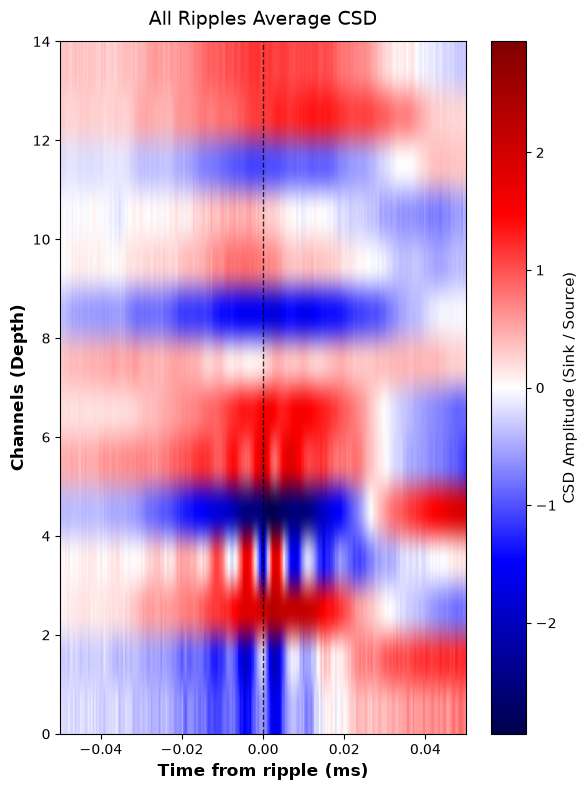

In [1]:
import tkinter as tk
from tkinter import filedialog
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Abrir una ventana para seleccionar el archivo .mat
root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)
file_path = filedialog.askopenfilename(
    title="Selecciona el archivo rippleCSDs.mat",
    filetypes=[("Archivos MAT", "*.mat"), ("Todos los archivos", "*.*")],
)
root.destroy()

if not file_path:
    raise FileNotFoundError("No se seleccionó ningún archivo.")

# Cargar el archivo seleccionado
mat_data = scipy.io.loadmat(file_path)

# 2. Acceder a la estructura 'rippleCSDs'
ripple_struct = mat_data['rippleCSDs'][0, 0]

# Extraer el vector de tiempo (t)
time = ripple_struct['t'].flatten()  # Array de 251 ms

# Extraer la matriz 3D (251 tiempo x 13 canales x 270 ripples -- en este caso)
csd = ripple_struct['CSDs']

# 3. All Ripples Average
# Promediamos sobre el eje 2 (los 270 eventos de ripples)
csd_avg = np.mean(csd, axis=2)

# Transponemos la matriz resultante (251, 13) -> (13, 251)
# Esto es para que las filas sean los CANALES (eje Y) y las columnas el TIEMPO (eje X)
csd_plot = csd_avg.T

# 4. Ajustar escala de color (Divergente y centrada en 0)
vmax = np.max(np.abs(csd_plot))

# 5. GRAFICAR
fig, ax = plt.subplots(figsize=(6, 8))

# Dibujar el mapa de calor usando los tiempos reales contenidos en 't'
im = ax.imshow(csd_plot, aspect='auto', cmap='seismic', 
               extent=[time[0], time[-1], 0, csd_plot.shape[0]],
               origin='lower', vmin=-vmax, vmax=vmax)

# Línea vertical discontinua en t = 0 ms (centro del ripple)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.8)

# Configuración de barra de color y etiquetas
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('CSD Amplitude (Sink / Source)', fontsize=11)

ax.set_xlabel('Time from ripple (ms)', fontsize=12, fontweight='bold')
ax.set_ylabel('Channels (Depth)', fontsize=12, fontweight='bold')
ax.set_title('All Ripples Average CSD', fontsize=14, pad=12)

plt.tight_layout()
plt.show()

Selecciona tu archivo .dat...
¡Cargado con éxito!
Matriz completa del .dat: (16, 3328493) (16 canales)


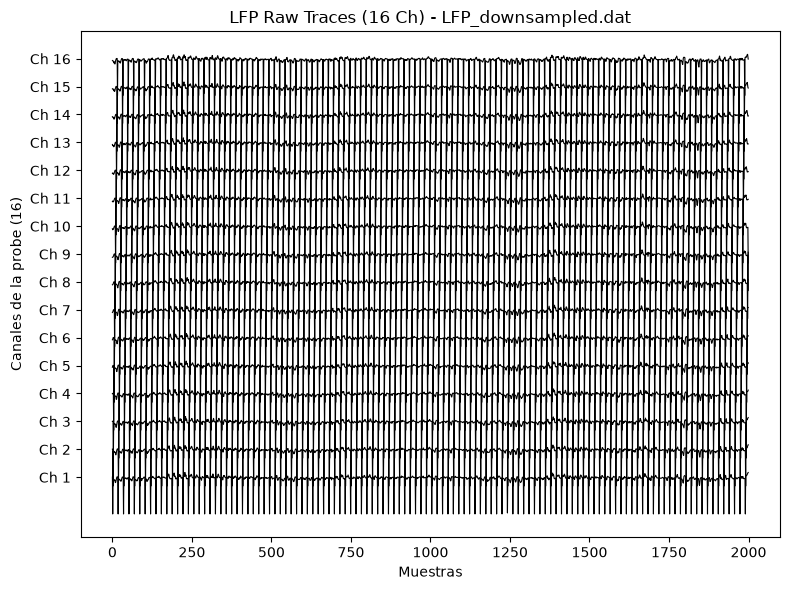

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import os

# 1. SELECCIONAR ARCHIVO .DAT
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

print("Selecciona tu archivo .dat...")
file_path = filedialog.askopenfilename(
    title="Selecciona el archivo de LFP (.dat)",
    filetypes=[("DAT Files", "*.dat"), ("All Files", "*.*")]
)

if not file_path:
    print("No seleccionaste ningún archivo.")
    exit()

filename = os.path.basename(file_path)

# 2. PARÁMETROS REALES DE TU REGISTRO
n_channels_probe = 16  # Canales FÍSICOS de la sonda en el .dat

# 3. LEER EL ARCHIVO
raw_data = np.fromfile(file_path, dtype=np.int16)

# Si al dividir sigue dando un ligero descuadre de algunos bytes al final, recortamos el sobrante exacto
remainder = len(raw_data) % n_channels_probe
if remainder != 0:
    raw_data = raw_data[:-remainder]

# 4. REORGANIZAR EN MATRIZ (16 Canales x Tiempo)
lfp_matrix = raw_data.reshape((-1, n_channels_probe)).T

print("¡Cargado con éxito!")
print(f"Matriz completa del .dat: {lfp_matrix.shape} (16 canales)")

# 5. SI SÓLO QUIERES QUEDARTE CON LOS 13 CANALES FUNCIONALES DEL CSD:
# Por ejemplo, si descartaste el canal 0 y los dos últimos:
# lfp_funcional = lfp_matrix[1:14, :] 

# 6. MOSTRAR PREVISUALIZACIÓN DE LOS 16 CANALES
fig, ax = plt.subplots(figsize=(8, 6))

time_window = 2000  # Primeros 2000 puntos
spacing = np.std(lfp_matrix) * 4

for ch in range(n_channels_probe):
    trace = lfp_matrix[ch, :time_window]
    ax.plot(trace + ch * spacing, color='black', linewidth=0.8)

ax.set_yticks([ch * spacing for ch in range(n_channels_probe)])
ax.set_yticklabels([f"Ch {ch+1}" for ch in range(n_channels_probe)])
ax.set_xlabel('Muestras')
ax.set_ylabel('Canales de la probe (16)')
ax.set_title(f'LFP Raw Traces (16 Ch) - {filename}')

plt.tight_layout()
plt.show()